Install libraries

In [10]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import io
# ── Inline dataset (no external file needed in Colab) ────────
csv_data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed

Alice,88,92,76,80,95,92,4.5,1

Bob,42,55,48,50,60,65,1.2,0

Charlie,75,70,80,68,88,85,3.0,1

Diana,95,98,91,89,97,98,6.0,1

Eve,38,42,50,45,55,58,0.8,0

Frank,60,65,72,58,70,78,2.5,1

Grace,55,48,44,52,62,60,1.5,0

Henry,82,79,85,77,90,88,4.0,1

Iris,70,74,68,65,78,80,3.5,1

Jack,30,35,40,28,45,50,0.5,0

Karen,65,60,70,62,75,72,2.8,1

Liam,48,52,44,55,58,62,1.8,0

Mia,91,94,88,92,96,95,5.5,1

Noah,58,62,55,60,68,70,2.0,0

Olivia,78,75,82,70,85,84,3.8,1"""

df = pd.read_csv(io.StringIO(csv_data))
df.to_csv("students.csv", index=False)  # also save to disk
subject_cols = ['math', 'science', 'english', 'history', 'pe']





Task 1: Data exploration with pandas

In [12]:
print("\n" + "="*60)
print("TASK 1 — DATA EXPLORATION WITH PANDAS")
print("="*60)
# ── 1. First 5 rows ───────────────────────────────────
print("\n--- First 5 rows ---")
print(df.head())
# ── 2. Shape and data types ───────────────────────────
print("\n--- Shape (rows × columns) ---")
print(df.shape)
print("\n--- Data types ---")
print(df.dtypes)
# ── 3. Summary statistics ─────────────────────────────
print("\n--- Summary Statistics ---")
print(df.describe())
# ── 4. Pass / Fail count ──────────────────────────────
print("\n--- Pass / Fail Count ---")
print(df['passed'].value_counts())
print("  1 = Pass  |  0 = Fail")
# ── 5. Average score per subject for pass vs fail ────────────
print("\n--- Average Scores: Passing Students ---")
print(df[df['passed'] == 1][subject_cols].mean())
print("\n--- Average Scores: Failing Students ---")
print(df[df['passed'] == 0][subject_cols].mean())
# ── 6. Student with highest overall average ──────────────────
df['temp_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['temp_avg'].idxmax()]
print(f"\n--- Student with Highest Overall Average ---")
print(f"  Name    : {top_student['name']}")
print(f"  Average : {top_student['temp_avg']:.2f}")
df.drop(columns=['temp_avg'], inplace=True)   # clean up temp column




TASK 1 — DATA EXPLORATION WITH PANDAS

--- First 5 rows ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

--- Shape (rows × columns) ---
(15, 9)

--- Data types ---
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64

Task 2:  Data visulaization with matprolib


TASK 2: Data visulaization with matprolib


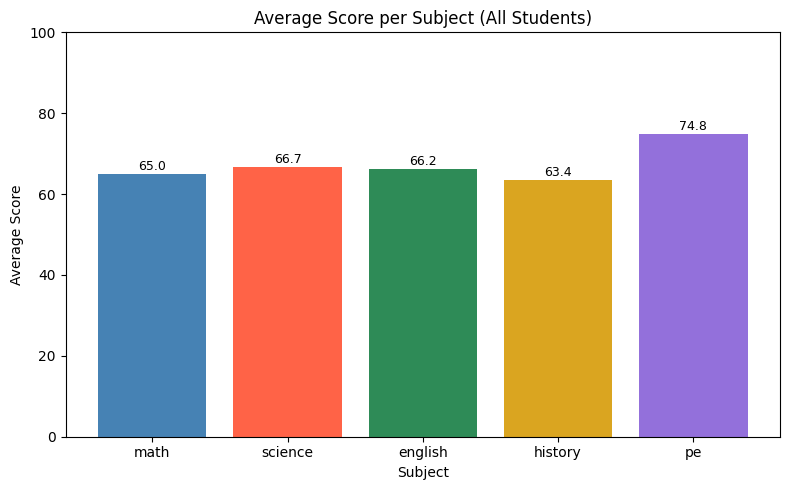

Saved: plot1_bar.png


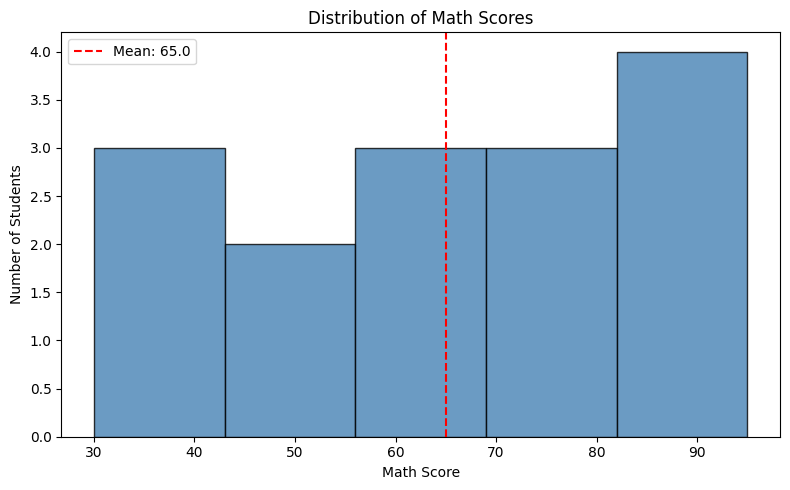

Saved: plot2_histogram.png


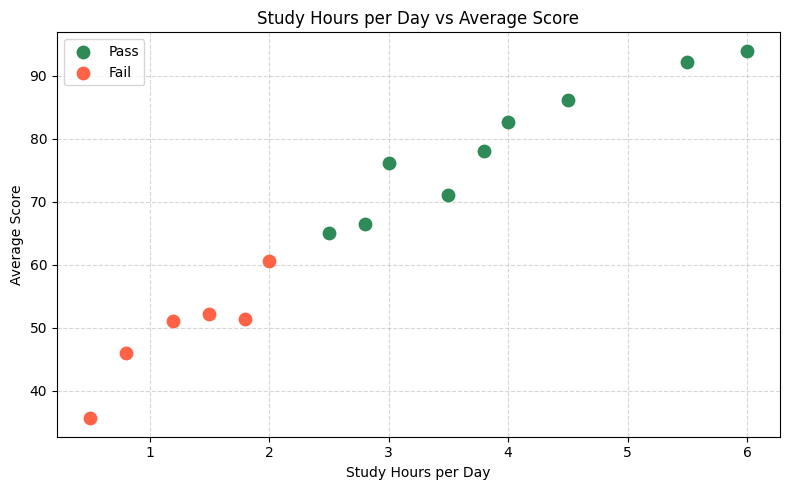

Saved: plot3_scatter.png


/tmp/ipykernel_5670/2402908842.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([pass_attendance, fail_attendance],


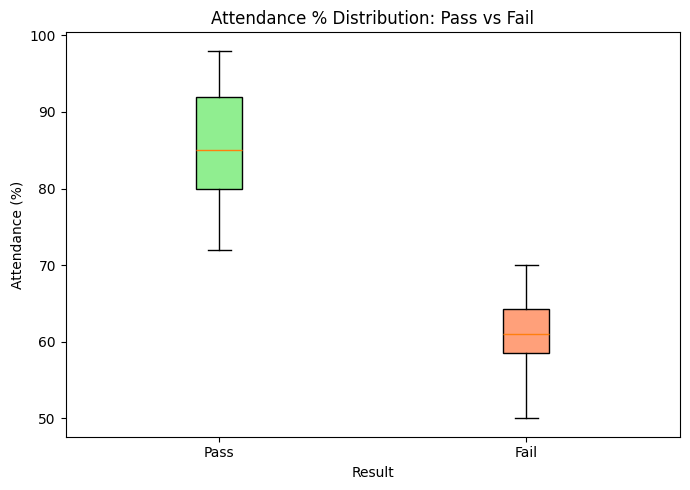

Saved: plot4_boxplot.png


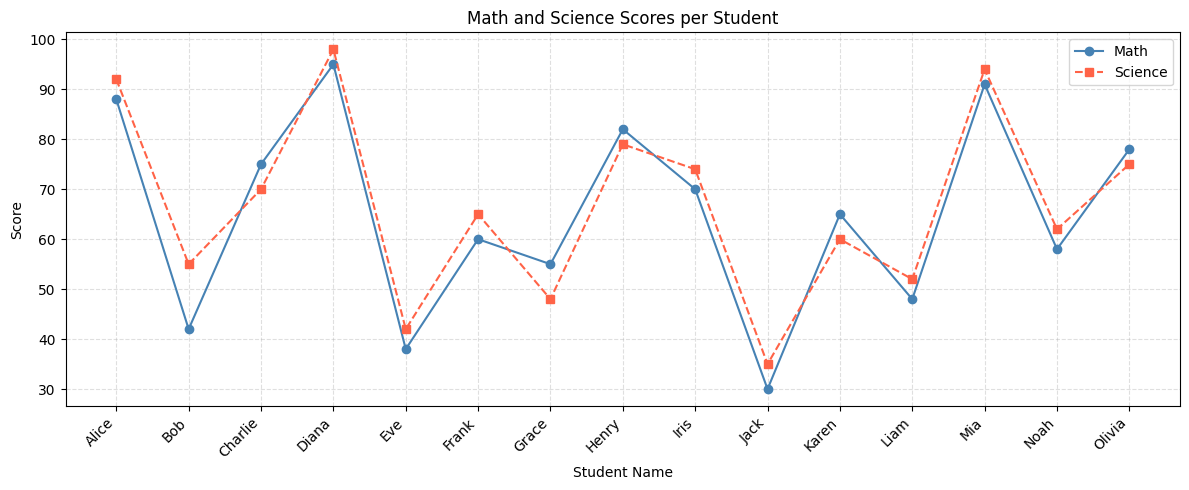

Saved: plot5_line.png


In [13]:
print("\n" + "="*60)
print("TASK 2: Data visulaization with matprolib")
print("="*60)
# Add avg_score column (used in scatter plot)
df['avg_score'] = df[subject_cols].mean(axis=1)
# ── Plot 1: Bar Chart — Average score per subject ────────
avg_per_subject = df[subject_cols].mean()
plt.figure(figsize=(8, 5))
plt.bar(avg_per_subject.index, avg_per_subject.values,
        color=['steelblue', 'tomato', 'seagreen', 'goldenrod', 'mediumpurple'])
plt.title("Average Score per Subject (All Students)")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.ylim(0, 100)
for i, v in enumerate(avg_per_subject.values):
    plt.text(i, v + 1, f"{v:.1f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("plot1_bar.png", dpi=150)
plt.show()
print("Saved: plot1_bar.png")
# ── Plot 2: Histogram — Distribution of math scores ──────────
mean_math = df['math'].mean()
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(mean_math, color='red', linestyle='--', linewidth=1.5,
            label=f"Mean: {mean_math:.1f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_histogram.png", dpi=150)
plt.show()
print("Saved: plot2_histogram.png")
# ── Plot 3: Scatter Plot — Study hours vs Avg score ──────────
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]
plt.figure(figsize=(8, 5))
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'],
            color='seagreen', label='Pass', s=80, zorder=3)
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'],
            color='tomato', label='Fail', s=80, zorder=3)
plt.title("Study Hours per Day vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plot3_scatter.png", dpi=150)
plt.show()
print("Saved: plot3_scatter.png")
# ── Plot 4: Box Plot — Attendance % for Pass vs Fail ─────────
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()
plt.figure(figsize=(7, 5))
bp = plt.boxplot([pass_attendance, fail_attendance],
                 labels=['Pass', 'Fail'],
                 patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightsalmon')
plt.title("Attendance % Distribution: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance (%)")
plt.tight_layout()
plt.savefig("plot4_boxplot.png", dpi=150)
plt.show()
print("Saved: plot4_boxplot.png")
# ── Plot 5: Line Plot — Math & Science score per student ──────
plt.figure(figsize=(12, 5))
plt.plot(df['name'], df['math'], marker='o', linestyle='-',
         color='steelblue', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--',
         color='tomato', label='Science')
plt.title("Math and Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("plot5_line.png", dpi=150)
plt.show()
print("Saved: plot5_line.png")

Task 3: Data Visualisation With Seaborn


Task 3: Data Visualisation With Seanborn


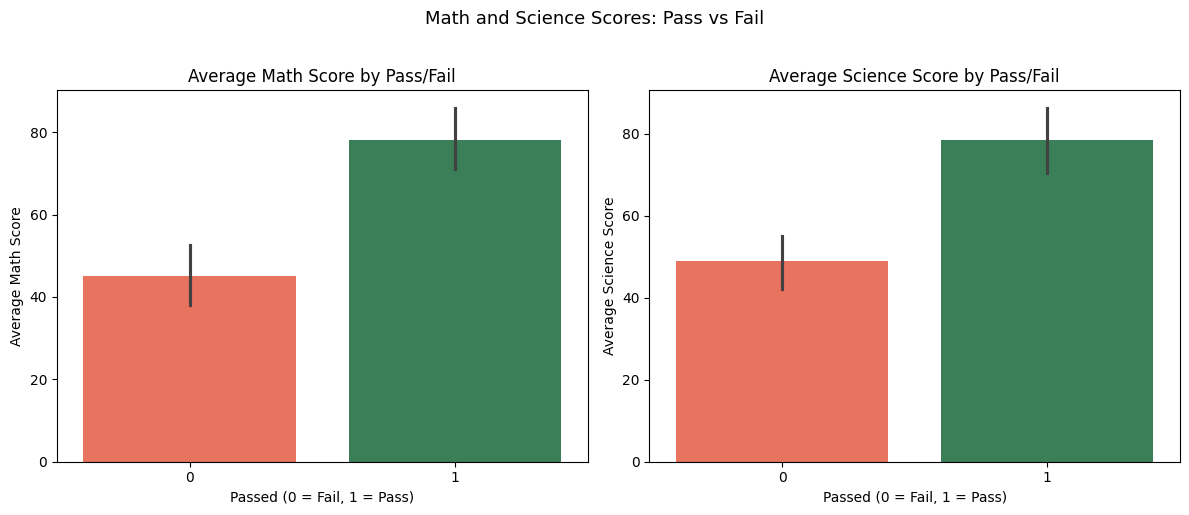

Saved: plot6_seaborn_bar.png


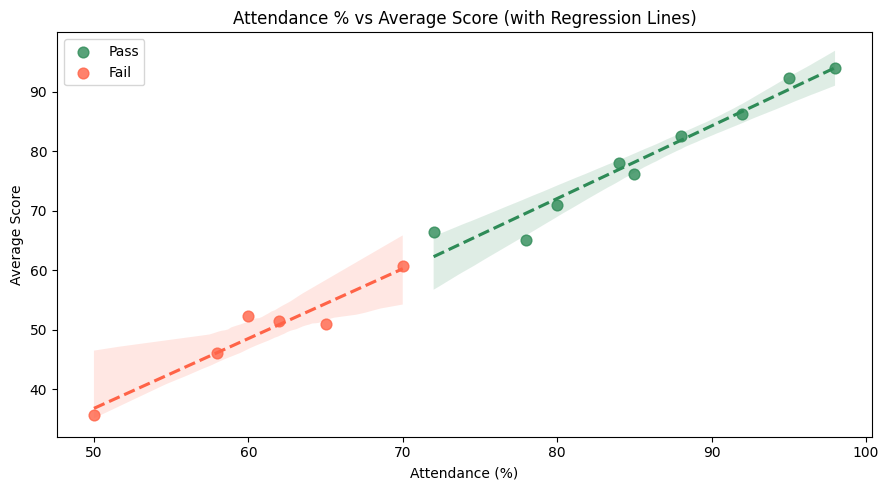

Saved: plot7_seaborn_scatter.png


In [14]:
print("\n" + "="*60)
print("Task 3: Data Visualisation With Seanborn")
print("="*60)
# ── Plot 6: Seaborn Bar Plot — Avg Math & Science by Pass/Fail
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x='passed', y='math', ax=ax1,
            hue='passed', palette={0: 'tomato', 1: 'seagreen'}, legend=False)
ax1.set_title("Average Math Score by Pass/Fail")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Average Math Score")
sns.barplot(data=df, x='passed', y='science', ax=ax2,
            hue='passed', palette={0: 'tomato', 1: 'seagreen'}, legend=False)
ax2.set_title("Average Science Score by Pass/Fail")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Average Science Score")
plt.suptitle("Math and Science Scores: Pass vs Fail", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot6_seaborn_bar.png")
# ── Plot 7: Seaborn Scatter + Regression — Attendance vs Avg Score
plt.figure(figsize=(9, 5))
sns.regplot(data=df[df['passed'] == 1],
            x='attendance_pct', y='avg_score',
            label='Pass', color='seagreen',
            scatter_kws={'s': 60}, line_kws={'linestyle': '--'})
sns.regplot(data=df[df['passed'] == 0],
            x='attendance_pct', y='avg_score',
            label='Fail', color='tomato',
            scatter_kws={'s': 60}, line_kws={'linestyle': '--'})
plt.title("Attendance % vs Average Score (with Regression Lines)")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png", dpi=150)
plt.show()
print("Saved: plot7_seaborn_scatter.png")

Task 4 — Machine Learning With Scikit-Learn


Task 4: Machine Learning With Scikit-Learn

Training samples : 12
Test samples     : 3

Training Accuracy: 100.0%
Test Accuracy    : 100.0%

--- Per-student Predictions ---
  Jack       | Actual: Fail | Predicted: Fail | ✅
  Liam       | Actual: Fail | Predicted: Fail | ✅
  Alice      | Actual: Pass | Predicted: Pass | ✅

--- Feature Coefficients (sorted by importance) ---
            Feature  Coefficient
            english     0.812513
     attendance_pct     0.521876
study_hours_per_day     0.484433
                 pe     0.474974
               math     0.437944
            science     0.323010
            history     0.262929


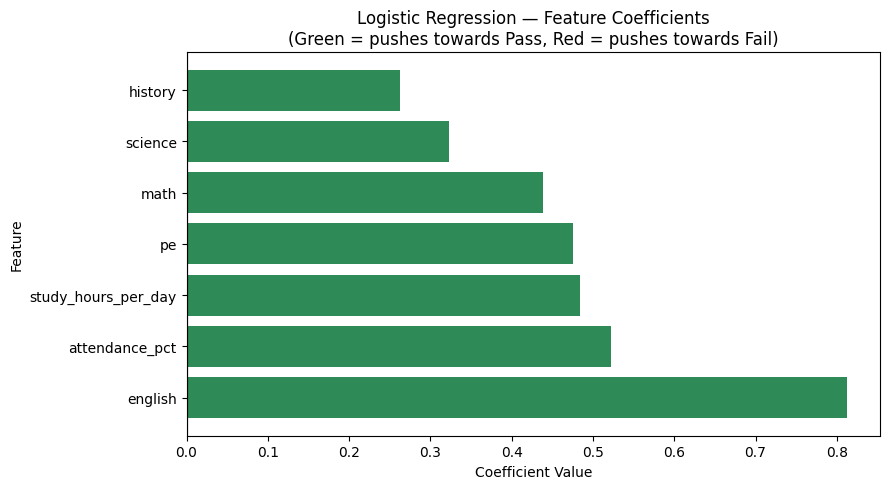

Saved: plot8_feature_importance.png

--- BONUS: Predicting for a New Student ---
  Input features : math=75, science=70, english=68, history=65, pe=80, attendance=82%, study=3.2h
  Prediction     : Pass ✅
  Probability    : Fail=9.20%  |  Pass=90.80%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [15]:
print("\n" + "="*60)
print("Task 4: Machine Learning With Scikit-Learn")
print("="*60)
# ── Step 1: Prepare Data ──────────────────────────────
feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]   # features — 'name' and 'passed' excluded
y = df['passed']       # target
# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
# Scale features — fit ONLY on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f"\nTraining samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
# ── Step 2: Train Logistic Regression ────────────────────────
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
print(f"\nTraining Accuracy: {train_acc * 100:.1f}%")
# ── Step 3: Evaluate on Test Set ─────────────────────────────
y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy    : {test_acc * 100:.1f}%")
print("\n--- Per-student Predictions ---")
test_names = df.loc[X_test.index, 'name']
for name, actual, predicted in zip(test_names, y_test, y_pred):
    actual_label    = "Pass" if actual    == 1 else "Fail"
    predicted_label = "Pass" if predicted == 1 else "Fail"
    correct = "✅" if actual == predicted else "❌"
    print(f"  {name:<10} | Actual: {actual_label:<4} | "
          f"Predicted: {predicted_label:<4} | {correct}")
# ── Step 4: Feature Importance (Coefficients) ────────────────
coefficients = model.coef_[0]
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)
print("\n--- Feature Coefficients (sorted by importance) ---")
print(coef_df.to_string(index=False))
# Horizontal bar chart of coefficients
colors = ['seagreen' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.figure(figsize=(9, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Logistic Regression — Feature Coefficients\n"
          "(Green = pushes towards Pass, Red = pushes towards Fail)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot8_feature_importance.png", dpi=150)
plt.show()
print("Saved: plot8_feature_importance.png")
# ── Step 5 (Bonus): Predict for a New Student ────────────────
print("\n--- BONUS: Predicting for a New Student ---")
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_scaled  = scaler.transform(new_student)
prediction  = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0]
result = "Pass ✅" if prediction == 1 else "Fail ❌"
print(f"  Input features : math=75, science=70, english=68, "
      f"history=65, pe=80, attendance=82%, study=3.2h")
print(f"  Prediction     : {result}")
print(f"  Probability    : Fail={probability[0]:.2%}  |  Pass={probability[1]:.2%}")
